In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("Mall_Customers.csv")

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [31]:
df.columns = df.columns.str.strip()

In [32]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

## Label encoding 

In [33]:
df["Gender"].unique()
gender_map = {"Male":0, "Female":1}
df["Gender"] = df["Gender"].map(gender_map)
df.dtypes

CustomerID                int64
Gender                    int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

## Grouping/Clustering features 

In [66]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]] # feature must be 2-D

## Scaling features

In [47]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

In [50]:
X_scaled = scaler.fit_transform(X)

## Model Training (K-Mean clustering)

In [54]:
from sklearn.cluster import KMeans

In [55]:
model = KMeans(n_clusters=3) # n_clusters = k = 3 distinct group

In [60]:
df["Cluster"] = model.fit_predict(X_scaled) # Add new col "Cluster" and group each customer

In [65]:
df.head()
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

## Visualisation

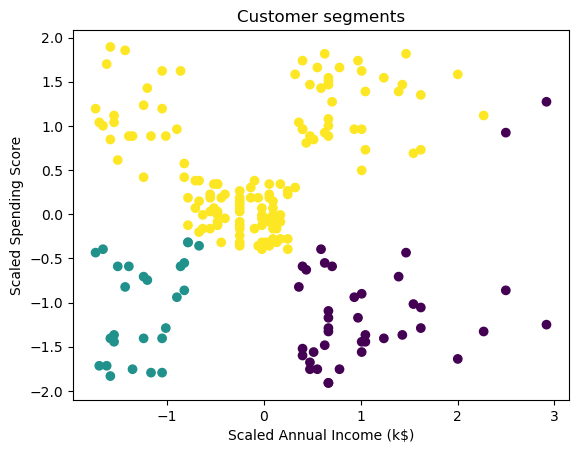

In [70]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["Cluster"])
# X_scaled[:,0] ==> Annual Income (k$)
# X_scaled[:,1] ==> Spending Score (0-100)

plt.xlabel("Scaled Annual Income (k$)")
plt.ylabel("Scaled Spending Score")
plt.title("Customer segments")

plt.show()